Normalize pixel values (0-255 → 0-1)
Reshape data for CNN input (28x28x1)
Split into train/validation/test sets
Create data augmentation
Save preprocessed data


In [2]:
print("hello world")

hello world


In [3]:
#imports 
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.model_selection import train_test_split

In [4]:
# tensorflow import
from tensorflow import keras
from tensorflow.keras.preprocessing.image import ImageDataGenerator

In [5]:

#random seed for reporoductivity (default 42)
np.random.seed(42)

#loading csv files 
train_data = pd.read_csv('../data/sign_mnist_train.csv')
test_data = pd.read_csv('../data/sign_mnist_test.csv')

#separating into feats and lables 
X_train_raw = train_data.drop('label', axis=1).values
y_train_raw = train_data['label'].values

X_test = test_data.drop('label', axis=1).values
y_test = test_data['label'].values

In [6]:
#print data before normalizing for comparisonn
print(f"\nBefore normalization:")
print(f"Min pixel value: {X_train_raw.min()}")
print(f"Max pixel value: {X_train_raw.max()}")
print(f"Mean pixel value: {X_train_raw.mean():.2f}")

#normalize to 0-1 
X_train_normalized = X_train_raw / 255.0
X_test_normalized = X_test / 255.0

#pritn after normalization for comparison 
print(f"\nAfter normalization:")
print(f"Min pixel value: {X_train_normalized.min()}")
print(f"Max pixel value: {X_train_normalized.max()}")
print(f"Mean pixel value: {X_train_normalized.mean():.3f}")


Before normalization:
Min pixel value: 0
Max pixel value: 255
Mean pixel value: 159.29

After normalization:
Min pixel value: 0.0
Max pixel value: 1.0
Mean pixel value: 0.625


### results

Before normalization:
Min pixel value: 0
Max pixel value: 255
Mean pixel value: 159.29

After normalization:
Min pixel value: 0.0
Max pixel value: 1.0
Mean pixel value: 0.625

### evaluation 

X_train shape: (27455, 784) (flat: 784 pixels)

After reshaping:
X_train shape: (27455, 28, 28, 1) (28x28x1 images)
X_test shape: (7172, 28, 28, 1)


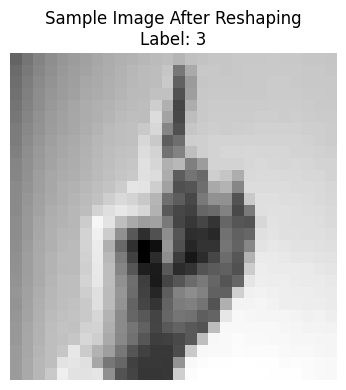

In [7]:
# reshape data for cnn 

#first we'll print data before reshaping 
print(f"X_train shape: {X_train_normalized.shape} (flat: 784 pixels)")

#reshape from (N, 784) to (N, 28, 28, 1)
# 28x28 = image dimensions
# 1 = grayscale (single channel)
X_train_reshaped = X_train_normalized.reshape(-1, 28, 28, 1)
X_test_reshaped = X_test_normalized.reshape(-1, 28, 28, 1)

print(f"\nAfter reshaping:")
print(f"X_train shape: {X_train_reshaped.shape} (28x28x1 images)")
print(f"X_test shape: {X_test_reshaped.shape}")


#visualize one image to verify reshaping worked
plt.figure(figsize=(4, 4))
plt.imshow(X_train_reshaped[0].reshape(28, 28), cmap='gray')
plt.title(f'Sample Image After Reshaping\nLabel: {y_train_raw[0]}')
plt.axis('off')
plt.tight_layout()
plt.show()


### results 
X_train shape: (27455, 784) (flat: 784 pixels)

After reshaping:
X_train shape: (27455, 28, 28, 1) (28x28x1 images)
X_test shape: (7172, 28, 28, 1)
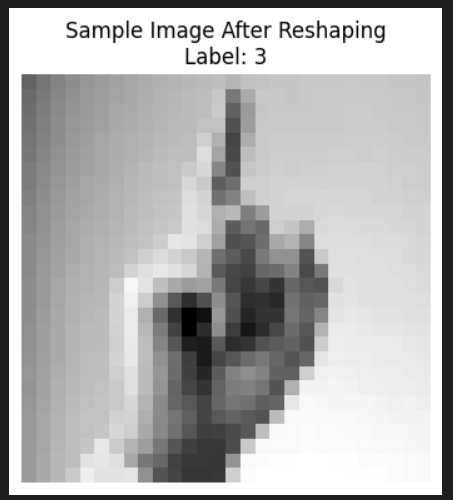

### evaluation 

In [8]:
#one hot encoding for lables

print(f"\nBefore one-hot encoding:")
print(f"y_train shape: {y_train_raw.shape}")
print(f"y_train sample: {y_train_raw[:5]}")
print(f"(These are label numbers: 0=A, 1=B, etc.)")


#one hot encode labels
#e.g. label 3 (letter D) becomes [0,0,0,1,0,0,0,...]
num_classes = y_train_raw.max() + 1  # A-Y (no J, no Z)

y_train_encoded = keras.utils.to_categorical(y_train_raw, num_classes)
y_test_encoded = keras.utils.to_categorical(y_test, num_classes)

print(f"\nAfter one-hot encoding:")
print(f"y_train shape: {y_train_encoded.shape}")
print(f"(Each label is now a vector of length {num_classes})")
print(f"\nexample - Original label: {y_train_raw[0]}")
print(f"one-hot encoded: {y_train_encoded[0]}")
print(f"(Position {y_train_raw[0]} = 1, all others = 0)")



Before one-hot encoding:
y_train shape: (27455,)
y_train sample: [ 3  6  2  2 13]
(These are label numbers: 0=A, 1=B, etc.)

After one-hot encoding:
y_train shape: (27455, 25)
(Each label is now a vector of length 25)

example - Original label: 3
one-hot encoded: [0. 0. 0. 1. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0.
 0.]
(Position 3 = 1, all others = 0)


### results 
Before one-hot encoding:
y_train shape: (27455,)
y_train sample: [ 3  6  2  2 13]
(These are label numbers: 0=A, 1=B, etc.)

After one-hot encoding:
y_train shape: (27455, 25)
(Each label is now a vector of length 25)

example - Original label: 3
one-hot encoded: [0. 0. 0. 1. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0.
 0.]
(Position 3 = 1, all others = 0)

### evaluation 


In [9]:
# train/validation split 

# Split training data into train (80%) and validation (20%)
# Use stratify to keep class balance
X_train, X_val, y_train, y_val = train_test_split(
    X_train_reshaped,
    y_train_encoded,
    test_size=0.2,
    random_state=42,
    stratify=y_train_raw  # Ensures balanced classes in both sets
)


# split summary 

print(f"   Training set:   {X_train.shape[0]:,} images ({X_train.shape[0]/len(X_train_reshaped)*100:.1f}%)")
print(f"   Validation set: {X_val.shape[0]:,} images ({X_val.shape[0]/len(X_train_reshaped)*100:.1f}%)")
print(f"   Test set:       {X_test_reshaped.shape[0]:,} images (held out)")


# Verify class balance in splits
train_label_indices = np.argmax(y_train, axis=1)
val_label_indices = np.argmax(y_val, axis=1)

print(f"   Training set: {len(np.unique(train_label_indices))} unique classes")
print(f"   Validation set: {len(np.unique(val_label_indices))} unique classes")

# Check distribution in validation set
val_dist = pd.Series(val_label_indices).value_counts().sort_index()
print(f"   Validation set - min per class: {val_dist.min()}, max: {val_dist.max()}")


   Training set:   21,964 images (80.0%)
   Validation set: 5,491 images (20.0%)
   Test set:       7,172 images (held out)
   Training set: 24 unique classes
   Validation set: 24 unique classes
   Validation set - min per class: 191, max: 259


### results 
   Training set:   21,964 images (80.0%)
   Validation set: 5,491 images (20.0%)
   Test set:       7,172 images (held out)
   Training set: 24 unique classes
   Validation set: 24 unique classes
   Validation set - min per class: 191, max: 259
### eval

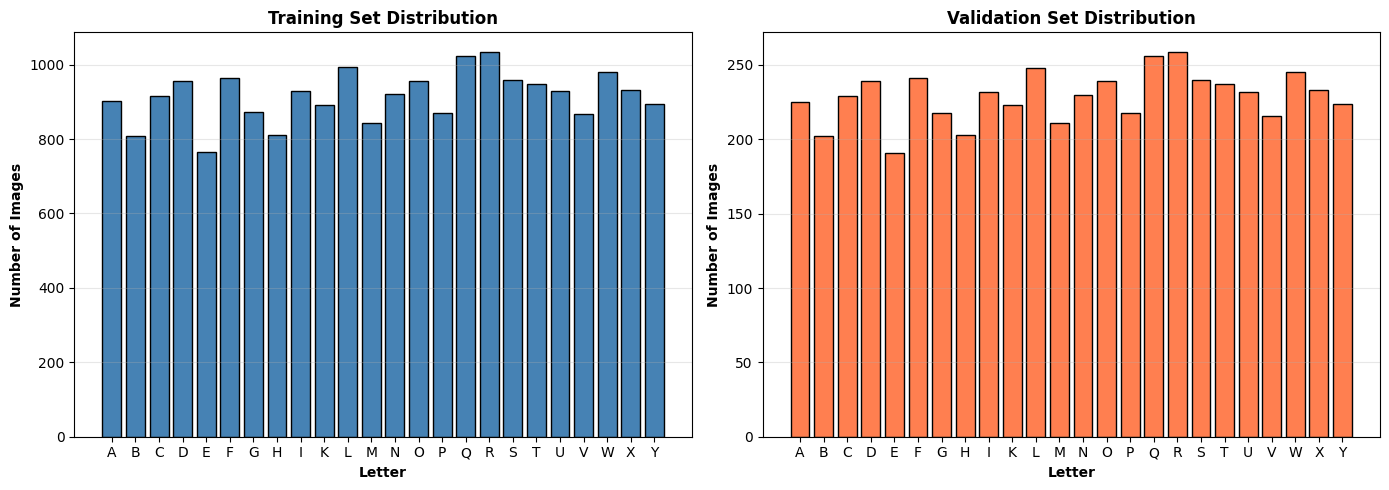

In [10]:
# verify class balance 
#vsualize class distribution in train vs validation
fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(14, 5))

#training set distribution
train_dist = pd.Series(train_label_indices).value_counts().sort_index()
letters = ['A', 'B', 'C', 'D', 'E', 'F', 'G', 'H', 'I', 
           'K', 'L', 'M', 'N', 'O', 'P', 'Q', 'R',
           'S', 'T', 'U', 'V', 'W', 'X', 'Y']

ax1.bar(range(24), train_dist.values, color='steelblue', edgecolor='black')
ax1.set_xlabel('Letter', fontweight='bold')
ax1.set_ylabel('Number of Images', fontweight='bold')
ax1.set_title('Training Set Distribution', fontweight='bold')
ax1.set_xticks(range(24))
ax1.set_xticklabels(letters)
ax1.grid(axis='y', alpha=0.3)

#validation set distribution
ax2.bar(range(24), val_dist.values, color='coral', edgecolor='black')
ax2.set_xlabel('Letter', fontweight='bold')
ax2.set_ylabel('Number of Images', fontweight='bold')
ax2.set_title('Validation Set Distribution', fontweight='bold')
ax2.set_xticks(range(24))
ax2.set_xticklabels(letters)
ax2.grid(axis='y', alpha=0.3)

plt.tight_layout()

#save to files 
plt.savefig('../results/figures/train_val_distribution.png', dpi=300, bbox_inches='tight')
plt.show()

### results 
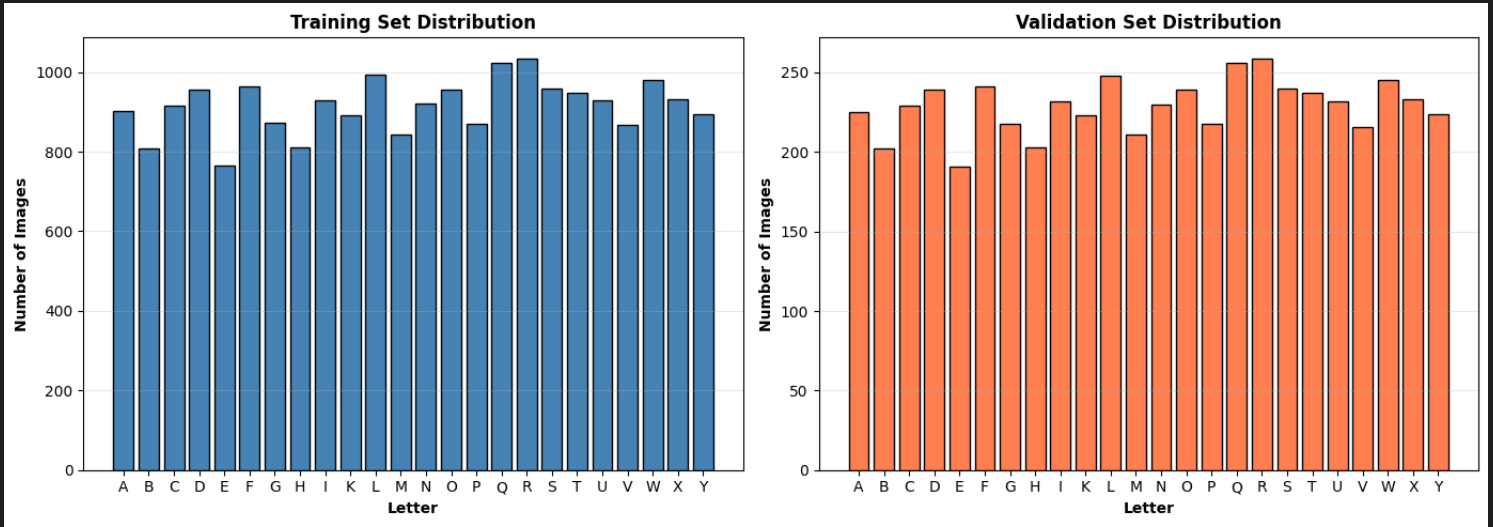

### eval

<>:48: SyntaxWarning: invalid escape sequence '\P'
<>:48: SyntaxWarning: invalid escape sequence '\P'
C:\Users\Maria\AppData\Local\Temp\ipykernel_2868\3363614198.py:48: SyntaxWarning: invalid escape sequence '\P'
  print("\PSA: Augmentation will be applied during training, not to the data directly")



Data augmentation helps model generalize better by creating
slightly modified versions of training images.
Rotation:10°
Shift:10%
Zoom: 10%


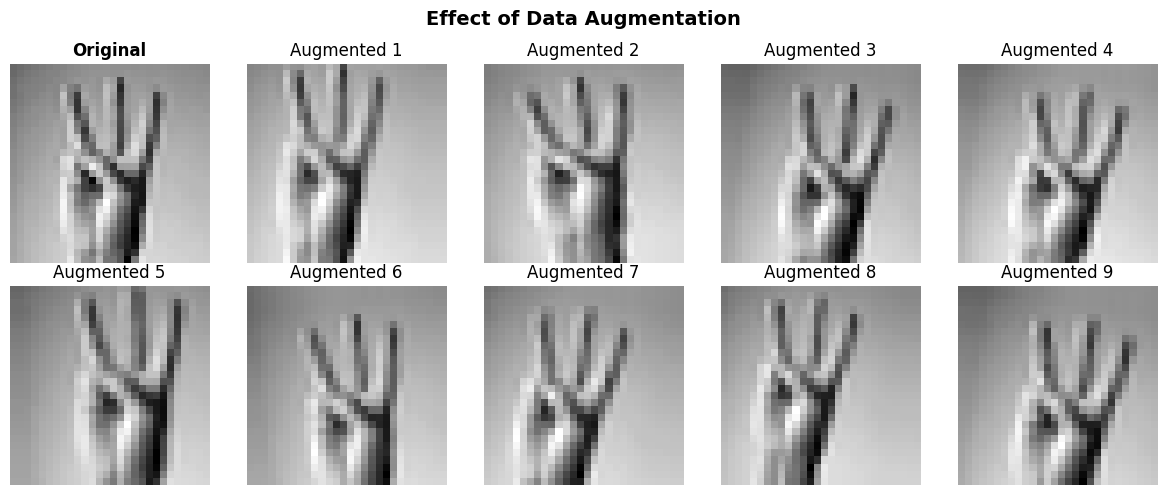

\PSA: Augmentation will be applied during training, not to the data directly


In [11]:
# this is optional 

#data augmentation 
print("\nData augmentation helps model generalize better by creating")
print("slightly modified versions of training images.")

# Create augmentation generator
# These transformations preserve hand gesture meaning
train_datagen = ImageDataGenerator(
    rotation_range=10,        #rotate ±10 degrees
    width_shift_range=0.1,    #shift horizontally ±10%
    height_shift_range=0.1,   #shift vertically ±10%
    zoom_range=0.1,           #zoom 10%
    fill_mode='nearest'       #fill empty pixels with nearest value
)

print(f"Rotation:10°")
print(f"Shift:10%")
print(f"Zoom: 10%")


#take one sample image
sample_image = X_train[0:1]  #shape: (1, 28, 28, 1)

#generate augmented versions
fig, axes = plt.subplots(2, 5, figsize=(12, 5))
axes = axes.flatten()

#original image
axes[0].imshow(sample_image[0].reshape(28, 28), cmap='gray')
axes[0].set_title('Original', fontweight='bold')
axes[0].axis('off')

#9 augmented versions
augmented_images = train_datagen.flow(sample_image, batch_size=1)
for i in range(1, 10):
    aug_image = next(augmented_images)
    axes[i].imshow(aug_image[0].reshape(28, 28), cmap='gray')
    axes[i].set_title(f'Augmented {i}')
    axes[i].axis('off')

plt.suptitle('Effect of Data Augmentation', fontweight='bold', fontsize=14)
plt.tight_layout()
plt.savefig('../results/figures/data_augmentation_examples.png', dpi=300, bbox_inches='tight')

plt.show()

print("\PSA: Augmentation will be applied during training, not to the data directly")

### results
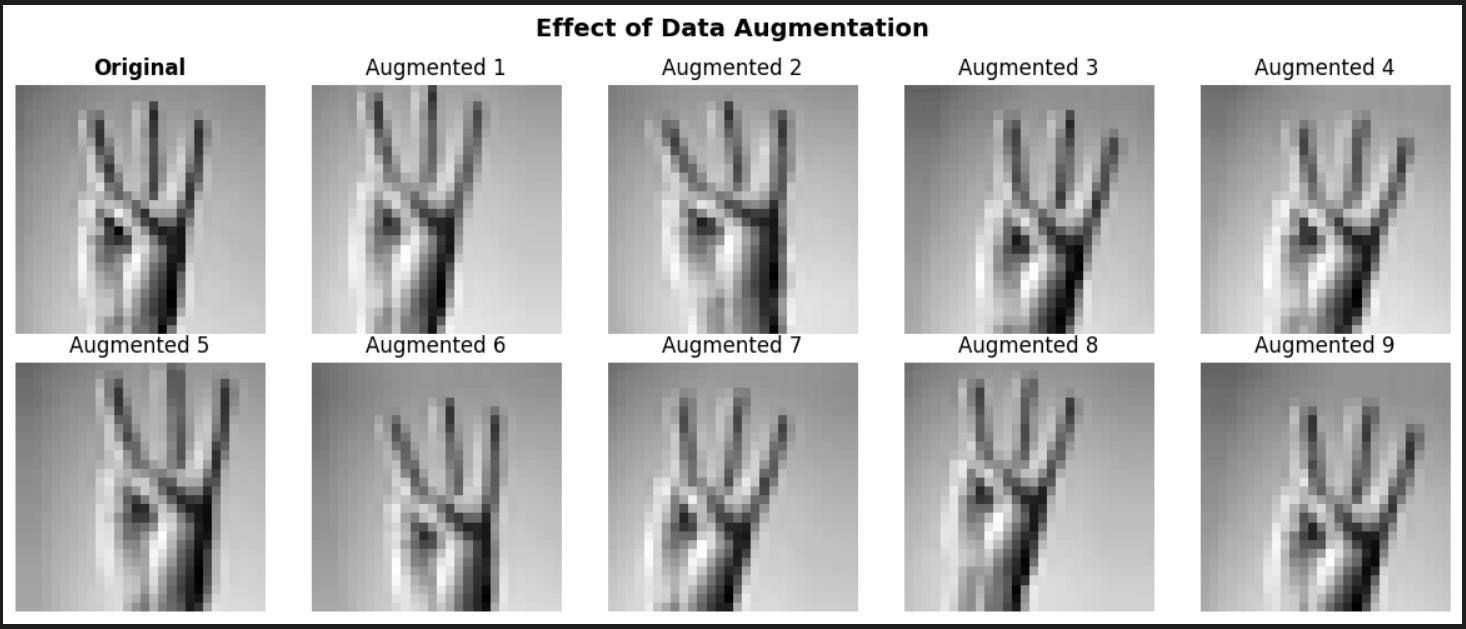

### eval
